# 📊 AI Models Benchmark Analysis (2026)

## 🎯 Objective
The goal of this project is to analyze and compare AI models based on intelligence, cost, speed, and latency to understand real-world trade-offs.

## 🧠 Step 1: Data Understanding
In this step, we will explore the dataset structure, features, and basic information to get familiar with the data before analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/ai_models_performance.csv")
df.head()

,Model,Context Window,Creator,Intelligence Index,Price (Blended USD/1M Tokens),Speed(median token/s),Latency (First Answer Chunk /s)
0,GPT-5.2 (xhigh),400k,OpenAI,51,$4.81,100,44.29
1,Claude Opus 4.5,200k,Anthropic,49,$10.00,79,1.70
2,Gemini 3 Pro Preview (high),1m,Google,48,$4.50,128,32.19
3,GPT-5.1 (high),400k,OpenAI,47,$3.44,127,26.50
4,Gemini 3 Flash,1m,Google,46,$1.13,224,11.62


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Model                            188 non-null    str    
 1   Context Window                   188 non-null    str    
 2   Creator                          188 non-null    str    
 3   Intelligence Index               188 non-null    str    
 4   Price (Blended USD/1M Tokens)    188 non-null    str    
 5   Speed(median token/s)            188 non-null    int64  
 6   Latency (First Answer Chunk /s)  188 non-null    float64
dtypes: float64(1), int64(1), str(5)
memory usage: 10.4 KB


In [4]:
df.describe()

,Speed(median token/s),Latency (First Answer Chunk /s)
count,188.000000,188.000000
mean,89.765957,3.313351
std,92.515404,12.711482
min,0.000000,0.000000
25%,14.500000,0.217500
50%,72.000000,0.520000
75%,127.250000,1.082500
max,550.000000,113.010000


In [5]:
df.isnull().sum()

Model                              0
Context Window                     0
Creator                            0
Intelligence Index                 0
Price (Blended USD/1M Tokens)      0
Speed(median token/s)              0
Latency (First Answer Chunk /s)    0
dtype: int64

## 📌 Observations from Data Understanding

- The dataset contains 188 rows and 7 columns.
- There are no missing values in any column, which means the dataset is clean in terms of completeness.
- Some columns have incorrect data types:
  - 'Context Window', 'Intelligence Index', and 'Price' are stored as strings but represent numerical values.
- Only 'Speed' and 'Latency' are currently in numeric format, which is why statistical summary is limited to these columns.
- Presence of symbols like 'k', 'm', and '$' indicates that data cleaning will be required before analysis.

## 🧹 Step 2: Data Cleaning

In this step, we will clean and transform the dataset by converting columns into appropriate data types and handling inconsistencies in the data.

In [6]:
def convert_context(x):
    x = str(x).strip().lower()
    try:
        if 'k' in x:
            return int(x.replace('k', '')) * 1000
        elif 'm' in x:
            return int(x.replace('m', '')) * 1000000
        else:
            return int(float(x))
    except:
        return None

df["Context Window"] = df["Context Window"].apply(convert_context)


df["Intelligence Index"] = (
    df["Intelligence Index"]
    .astype(str)
    .str.extract(r'(\d+)')[0]       
    .pipe(pd.to_numeric, errors='coerce')  
    .astype("Int64")                
)


df["Price (Blended USD/1M Tokens)"] = (
    df["Price (Blended USD/1M Tokens)"]
    .astype(str)
    .str.replace('$', '', regex=False)
    .astype(float)
)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Model                            188 non-null    str    
 1   Context Window                   188 non-null    int64  
 2   Creator                          188 non-null    str    
 3   Intelligence Index               182 non-null    Int64  
 4   Price (Blended USD/1M Tokens)    188 non-null    float64
 5   Speed(median token/s)            188 non-null    int64  
 6   Latency (First Answer Chunk /s)  188 non-null    float64
dtypes: Int64(1), float64(2), int64(2), str(2)
memory usage: 10.6 KB


## 📌Data Cleaning — Observations

- The 'Context Window' column was successfully converted from string format (e.g., "400k", "1m") into numeric values.
- The 'Intelligence Index' column contained inconsistent formats such as "41 E" and hidden characters like newline (`\n`), which were cleaned by extracting only numeric values.
- Some values in 'Intelligence Index' could not be converted and resulted in missing values.
- The 'Price (Blended USD/1M Tokens)' column was cleaned by removing the '$' symbol and converting it into float.
- After cleaning, most columns are now in appropriate numeric formats, making the dataset ready for analysis.

## 📊 Step 3: Univariate Analysis (EDA - Part 1)

In this step, we will analyze individual numerical features to understand their distribution, central tendency, and spread.

We will focus on:
- Intelligence Index
- Price
- Speed
- Latency

In [8]:
df["Intelligence Index"].describe()

count        182.0
mean     21.730769
std      10.761043
min            6.0
25%           14.0
50%           20.0
75%          28.75
max           51.0
Name: Intelligence Index, dtype: Float64

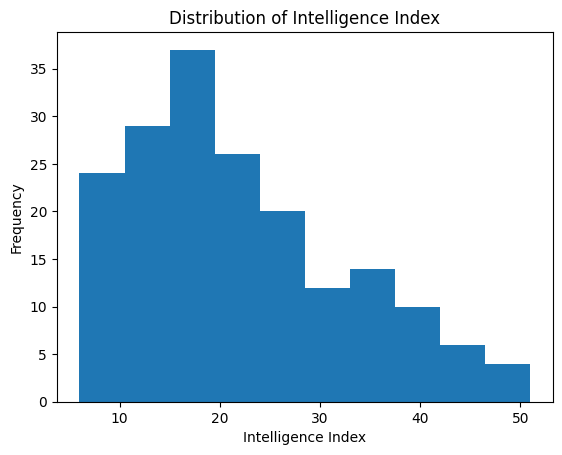

In [9]:
plt.hist(df["Intelligence Index"])
plt.title("Distribution of Intelligence Index")
plt.xlabel("Intelligence Index")
plt.ylabel("Frequency")
plt.show()

### 📊 Intelligence Index Analysis

- Most models have intelligence scores between 15 and 30.
- The distribution is right-skewed, meaning there are fewer high-intelligence models.
- A small number of models have very high scores (above 40), indicating possible high-end outliers.
- The average intelligence score is around 21, suggesting most models are in the moderate performance range.

In [10]:
print("Mean:", df["Intelligence Index"].mean())
print("Median:", df["Intelligence Index"].median())

Mean: 21.73076923076923
Median: 20.0


### 📊 Intelligence Index Analysis

- The mean (21.7) is greater than the median (20), indicating a right-skewed distribution.
- This suggests that a small number of models with very high intelligence scores (40–50) are pulling the average upward.
- Most models have intelligence scores in the range of 15–30, representing moderate performance.
- Values above 40 are relatively rare compared to the main distribution.
- Using the IQR method, values above approximately 50 can be considered outliers.
- Overall, the dataset shows that most models are moderately capable, with only a few high-performing models.

## 💰 Price Analysis (Univariate EDA)

In this step, we analyze the distribution of model pricing to understand cost patterns, common price ranges, and presence of expensive or budget models.

In [13]:
df['Price (Blended USD/1M Tokens)'].describe()

count    188.000000
mean       0.972553
std        1.644017
min        0.000000
25%        0.000000
50%        0.300000
75%        0.900000
max       10.000000
Name: Price (Blended USD/1M Tokens), dtype: float64

### 📊 Price Analysis

- The average price is around $0.97, indicating that most models are relatively low-cost.
- The price range varies significantly from $0 to $10, showing high variation.
- 50% of models cost less than $0.3, and 75% cost less than $0.9, indicating that most models are very affordable.
- A small number of expensive models increase the average price.

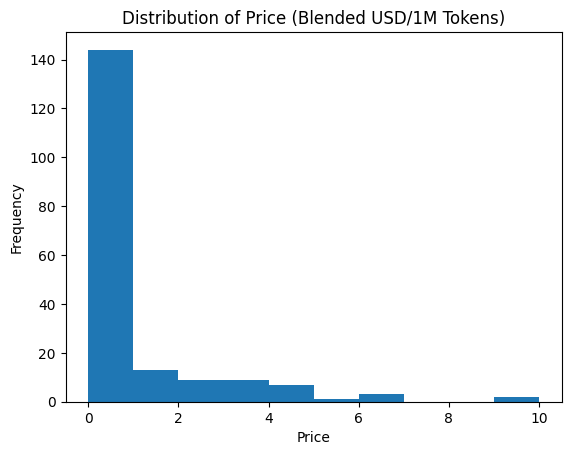

In [14]:
plt.hist(df['Price (Blended USD/1M Tokens)'])
plt.title("Distribution of Price (Blended USD/1M Tokens)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### 💰 Price Distribution Analysis

- Most models are concentrated in the low price range (0–1), indicating that the majority are very affordable.
- The distribution is highly right-skewed, meaning a few expensive models increase the overall range.
- Very few models exist in higher price ranges (5–10), showing that expensive models are rare.
- The pricing pattern suggests that the AI market is dominated by low-cost models, with only a small number of premium models.

### 💰 Price Insights

- The price distribution is right-skewed because most models are low-cost, while a few expensive models create a long tail.
- A large number of models are available in the affordable range (0–1), making AI accessible.
- Only a small number of models fall into higher price ranges (5–10), representing premium offerings.
- There appears to be a potential relationship between model intelligence and price, which will be explored further.